# 노트북 01 — 데이터 파이프라인 + 품질 진단
## 프로젝트 3: 차종 구성 프로파일링

**목적**: 3개 교차로 raw CSV(약 366만행)를 평일(공휴일 제외) 기준으로 필터링하고,
접근로 × 시간대그룹(6구간) × 차종으로 집계한 구성비 테이블(66행)을 만든다.
이후 노트북에서 이 테이블로 군집화를 진행한다.

**폴더 구조 가정**
```
파란학기_응용_2nd/
├─ data/
│  ├─ raw/          ← 원본 6개 CSV (이 노트북이 읽는 곳)
│  └─ processed/    ← 이 노트북이 결과를 저장하는 곳
├─ notebooks/        ← 이 노트북이 위치한 곳 (01_pipeline_quality_check.ipynb)
└─ outputs/
   └─ figures/       ← 이 노트북이 그래프를 저장하는 곳
```

**방법론 원칙 (기존 프로젝트에서 확립)**
- 통계적 일괄 이상치 제거(IQR 등) 금지 — 물리적으로 불가능한 값만 제거
- 평균 대신 중앙값 우선 검토
- 평일(공휴일 제외)만 사용 — 주말 효과는 지점 간 거의 균일한 배율로 나타나 프로파일 성격 구분에 기여도가 낮다는 것을 사전 분석에서 확인함


## 0. 라이브러리 임포트 및 환경 설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# 한글 폰트 설정 (Windows 기준 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)


In [3]:
# holidays 라이브러리가 없다면 아래 셀의 주석을 풀고 먼저 설치하세요.
!pip install holidays
import holidays


## 1. 경로 설정

노트북이 `notebooks/` 폴더 안에 있다는 가정하에 상대경로를 씁니다.
실행 위치가 다르면 `BASE_DIR`만 수정하면 됩니다.

In [4]:
BASE_DIR = Path('..')
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIG_DIR = BASE_DIR / 'outputs' / 'figures'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILES = {
    '오리삼거리': RAW_DIR / '오리삼거리.csv',
    '동막교사거리': RAW_DIR / '동막교사거리.csv',
    '미금역사거리': RAW_DIR / '미금역사거리.csv',
}
REF_FILES = {
    '접근로정보': RAW_DIR / '접근로정보.csv',
    '차종구분': RAW_DIR / '차종구분.csv',
    '이동류구분': RAW_DIR / '이동류구분.csv',
}

for name, path in {**RAW_FILES, **REF_FILES}.items():
    status = 'OK' if path.exists() else '!! 파일 없음 - 경로 확인 필요'
    print(f'{name:12s} : {path}  [{status}]')


오리삼거리        : ..\data\raw\오리삼거리.csv  [OK]
동막교사거리       : ..\data\raw\동막교사거리.csv  [OK]
미금역사거리       : ..\data\raw\미금역사거리.csv  [OK]
접근로정보        : ..\data\raw\접근로정보.csv  [OK]
차종구분         : ..\data\raw\차종구분.csv  [OK]
이동류구분        : ..\data\raw\이동류구분.csv  [OK]


## 2. 참조 테이블 로드 (차종, 이동류, 접근로명)

하드코딩된 매핑 대신, 프로젝트 지식에 있는 실제 참조 CSV를 그대로 읽어서 사용합니다.

In [5]:
car_ref = pd.read_csv(REF_FILES['차종구분'])
move_ref = pd.read_csv(REF_FILES['이동류구분'])
avenue_ref = pd.read_csv(REF_FILES['접근로정보'])

print('=== 차종구분 ===')
display(car_ref)
print('\n=== 이동류구분 ===')
display(move_ref)
print('\n=== 접근로정보 (일부) ===')
display(avenue_ref[['AvenueSeq', 'AvenueName', 'IntersectionSeq']].sort_values('AvenueSeq'))


=== 차종구분 ===


,CarModelType,CarModelName
0,1,승용차
1,2,소형버스
2,3,대형버스
3,4,소형트럭
4,5,대형트럭
5,6,오토바이



=== 이동류구분 ===


,MovementType,MovementName
0,1,직진
1,2,좌회전
2,3,우회전
3,4,유턴



=== 접근로정보 (일부) ===


,AvenueSeq,AvenueName,IntersectionSeq
0,16,오리역 방면,5
1,17,오리교1사거리 방면,5
2,18,농수산물센터 방면,5
3,142,청송마을 사거리 방면,37
4,143,까치마을사거리 방면,37
5,144,미금역 방면,37
6,145,정자일로 방면,37
7,183,동막교삼거리 방면,48
8,184,오리공원 방면,48
9,185,오리역 방면,48


### 2-1. 주의: `AvenueName`만으로는 접근로를 구분할 수 없음

`AvenueSeq`는 전역적으로 유일하지만(11개), `AvenueName`은 서로 다른 교차로에서 같은
방면 이름이 재사용되는 경우가 있습니다(예: 오리삼거리의 "오리역 방면"과 동막교사거리의
"오리역 방면"은 서로 다른 물리적 위치인데 이름이 같음). 이름만 믿고 groupby하면
11개여야 할 접근로가 10개로 뭉개지는 실수가 생깁니다. 아래 셀에서 이를 확인하고,
`AvenueSeq`를 기준 키로 삼아 (원본 교차로명 + 방면명)으로 유일한 표시 라벨을 만듭니다.

In [ ]:
# AvenueSeq -> AvenueName 매핑 자체는 유일한지 확인 (이건 문제 없어야 정상)
avenue_map_check = avenue_ref.groupby('AvenueSeq')['AvenueName'].nunique()
assert (avenue_map_check == 1).all(), 'AvenueSeq -> AvenueName 매핑이 유일하지 않습니다.'
print('OK: AvenueSeq -> AvenueName은 1:1 매핑')

# 반대 방향(AvenueName -> AvenueSeq)이 유일한지 확인 - 이게 실제 문제 지점
name_to_seq = avenue_ref.groupby('AvenueName')['AvenueSeq'].nunique()
name_collisions = name_to_seq[name_to_seq > 1]
if len(name_collisions) > 0:
    print(f'!! AvenueName 중복 발견 ({len(name_collisions)}건) - 서로 다른 AvenueSeq가 같은 이름을 씁니다:')
    for nm in name_collisions.index:
        display(avenue_ref.loc[avenue_ref['AvenueName'] == nm, ['AvenueSeq', 'AvenueName', 'IntersectionSeq']])
else:
    print('OK: AvenueName도 유일합니다.')


In [6]:
# raw 데이터를 로드하면서 태그해 둔 SourceIntersection을 이용해
# AvenueSeq -> (원본 교차로명, 방면명)으로 유일한 표시 라벨을 만든다.
# (아래 5번 셀에서 all_df를 만들 때 SourceIntersection이 이미 존재하므로, 여기서는 raw 파일명을 직접 다시 매핑)
intersection_of_avenue = {}
for name, path in RAW_FILES.items():
    seqs = pd.read_csv(path, usecols=['AvenueSeq'])['AvenueSeq'].unique()
    for s in seqs:
        intersection_of_avenue[s] = name

avenue_ref['SourceIntersection'] = avenue_ref['AvenueSeq'].map(intersection_of_avenue)
avenue_ref['UniqueLabel'] = avenue_ref['SourceIntersection'] + '_' + avenue_ref['AvenueName'].str.replace(r'\s+', '', regex=True)

# 이제 UniqueLabel 기준으로는 충돌이 없는지 재확인
label_check = avenue_ref.groupby('UniqueLabel')['AvenueSeq'].nunique()
assert (label_check == 1).all(), 'UniqueLabel도 여전히 충돌합니다 - 추가 확인 필요'
print('OK: UniqueLabel(교차로명+방면명) 기준으로는 11개 접근로가 모두 유일하게 구분됩니다.')
display(avenue_ref[['AvenueSeq', 'SourceIntersection', 'AvenueName', 'UniqueLabel']].sort_values('AvenueSeq'))

avenue_map = avenue_ref.set_index('AvenueSeq')['UniqueLabel'].to_dict()
car_map = car_ref.set_index('CarModelType')['CarModelName'].to_dict()
move_map = move_ref.set_index('MovementType')['MovementName'].to_dict()


OK: UniqueLabel(교차로명+방면명) 기준으로는 11개 접근로가 모두 유일하게 구분됩니다.


,AvenueSeq,SourceIntersection,AvenueName,UniqueLabel
0,16,오리삼거리,오리역 방면,오리삼거리_오리역방면
1,17,오리삼거리,오리교1사거리 방면,오리삼거리_오리교1사거리방면
2,18,오리삼거리,농수산물센터 방면,오리삼거리_농수산물센터방면
3,142,미금역사거리,청송마을 사거리 방면,미금역사거리_청송마을사거리방면
4,143,미금역사거리,까치마을사거리 방면,미금역사거리_까치마을사거리방면
5,144,미금역사거리,미금역 방면,미금역사거리_미금역방면
6,145,미금역사거리,정자일로 방면,미금역사거리_정자일로방면
7,183,동막교사거리,동막교삼거리 방면,동막교사거리_동막교삼거리방면
8,184,동막교사거리,오리공원 방면,동막교사거리_오리공원방면
9,185,동막교사거리,오리역 방면,동막교사거리_오리역방면


## 3. 원본 데이터 로드 및 기본 검증

In [7]:
dfs = []
for name, path in RAW_FILES.items():
    df = pd.read_csv(path)
    df['SourceIntersection'] = name
    dfs.append(df)
    print(f'{name}: {df.shape[0]:,}행, 컬럼={list(df.columns)}')

all_df = pd.concat(dfs, ignore_index=True)
print(f'\n합계: {len(all_df):,}행')
all_df.head()


오리삼거리: 898,568행, 컬럼=['IntersectionSeq', 'AvenueSeq', 'CollectedDate', 'LaneNum', 'CarModelType', 'MovementType', 'Volume', 'Speed', 'SourceIntersection']
동막교사거리: 1,104,658행, 컬럼=['IntersectionSeq', 'AvenueSeq', 'CollectedDate', 'LaneNum', 'CarModelType', 'MovementType', 'Volume', 'Speed', 'SourceIntersection']
미금역사거리: 1,657,362행, 컬럼=['IntersectionSeq', 'AvenueSeq', 'CollectedDate', 'LaneNum', 'CarModelType', 'MovementType', 'Volume', 'Speed', 'SourceIntersection']

합계: 3,660,588행


,IntersectionSeq,AvenueSeq,CollectedDate,LaneNum,CarModelType,MovementType,Volume,Speed,SourceIntersection
0,5,16,2023-11-07 16:00:00.000,1,1,2,16,14.8125,오리삼거리
1,5,16,2023-11-07 16:00:00.000,1,3,2,8,14.5000,오리삼거리
2,5,16,2023-11-07 16:00:00.000,1,5,2,1,9.0000,오리삼거리
3,5,16,2023-11-07 16:00:00.000,2,1,1,271,19.1033,오리삼거리
4,5,16,2023-11-07 16:00:00.000,2,2,1,1,8.0000,오리삼거리


In [8]:
# 기본 검증: 원본 행 수가 이전에 확인한 3,660,588행과 일치하는지
assert len(all_df) == 3660588, f'행 수가 예상과 다릅니다: {len(all_df):,}'
print('OK: 행 수 일치 확인')

# 결측치 체크
print('\n결측치:')
print(all_df.isna().sum())

# Volume, Speed 물리적 불가능 값 체크 (음수 등) - IQR 아님, 물리 법칙 위반만 확인
print(f"\nVolume < 0 개수: {(all_df['Volume'] < 0).sum()}")
print(f"Speed < 0 개수: {(all_df['Speed'] < 0).sum()}")


OK: 행 수 일치 확인

결측치:
IntersectionSeq       0
AvenueSeq             0
CollectedDate         0
LaneNum               0
CarModelType          0
MovementType          0
Volume                0
Speed                 0
SourceIntersection    0
dtype: int64

Volume < 0 개수: 0
Speed < 0 개수: 0


In [9]:
all_df['CollectedDate'] = pd.to_datetime(all_df['CollectedDate'])
all_df['AvenueName'] = all_df['AvenueSeq'].map(avenue_map)  # 2-1에서 만든 유일 라벨(교차로명_방면명) 사용
all_df['CarModelName'] = all_df['CarModelType'].map(car_map)
all_df['MovementName'] = all_df['MovementType'].map(move_map)

# 매핑 안 된 값이 있는지 확인 (있으면 참조 테이블 누락)
for col, src in [('AvenueName', 'AvenueSeq'), ('CarModelName', 'CarModelType'), ('MovementName', 'MovementType')]:
    n_missing = all_df[col].isna().sum()
    if n_missing > 0:
        print(f'!! {col} 매핑 실패 {n_missing}건 — {src} 원본 고유값 확인 필요')
        print(all_df.loc[all_df[col].isna(), src].unique())
    else:
        print(f'OK: {col} 매핑 완료 (결측 0건)')


OK: AvenueName 매핑 완료 (결측 0건)
OK: CarModelName 매핑 완료 (결측 0건)
OK: MovementName 매핑 완료 (결측 0건)


## 4. 평일 필터링 (공휴일 제외)

프로젝트 1과 동일한 기준: 평일(월~금)이면서 대한민국 공휴일이 아닌 날만 사용합니다.
데이터 기간(2023-11-07~2025-09-04)에 걸친 공휴일 목록을 `holidays` 라이브러리로 생성합니다.

In [10]:
kr_holidays = holidays.KR(years=[2023, 2024, 2025])

all_df['date'] = all_df['CollectedDate'].dt.date
all_df['dow'] = all_df['CollectedDate'].dt.dayofweek  # 0=월 ... 6=일
all_df['is_weekday'] = all_df['dow'] < 5
all_df['is_holiday'] = all_df['date'].isin(kr_holidays)
all_df['use_for_analysis'] = all_df['is_weekday'] & (~all_df['is_holiday'])

n_total = len(all_df)
n_weekday_only = all_df['is_weekday'].sum()
n_final = all_df['use_for_analysis'].sum()

print(f'전체: {n_total:,}행')
print(f'평일(요일 기준): {n_weekday_only:,}행 ({n_weekday_only/n_total*100:.1f}%)')
print(f'평일 + 공휴일 제외: {n_final:,}행 ({n_final/n_total*100:.1f}%)')
print(f'평일이지만 공휴일이라 제외된 행: {n_weekday_only - n_final:,}행')

weekday_df = all_df[all_df['use_for_analysis']].copy()


전체: 3,660,588행
평일(요일 기준): 2,714,868행 (74.2%)
평일 + 공휴일 제외: 2,587,325행 (70.7%)
평일이지만 공휴일이라 제외된 행: 127,543행


In [11]:
# 실제로 제외된 공휴일 목록 확인 (검증용)
excluded_dates = sorted(all_df.loc[all_df['is_weekday'] & all_df['is_holiday'], 'date'].unique())
print(f'평일 중 공휴일로 제외된 날짜 수: {len(excluded_dates)}')
for d in excluded_dates:
    print(f'  {d}  ({kr_holidays.get(d)})')


평일 중 공휴일로 제외된 날짜 수: 28
  2023-12-25  (기독탄신일)
  2024-01-01  (신정연휴)
  2024-02-09  (설날 전날)
  2024-02-12  (설날 대체 휴일)
  2024-03-01  (삼일절)
  2024-04-10  (국회의원 선거일)
  2024-05-06  (어린이날 대체 휴일)
  2024-05-15  (부처님오신날)
  2024-06-06  (현충일)
  2024-08-15  (광복절)
  2024-09-16  (추석 전날)
  2024-09-17  (추석)
  2024-09-18  (추석 다음날)
  2024-10-01  (국군의 날)
  2024-10-03  (개천절)
  2024-10-09  (한글날)
  2024-12-25  (기독탄신일)
  2025-01-01  (신정연휴)
  2025-01-27  (임시공휴일)
  2025-01-28  (설날 전날)
  2025-01-29  (설날)
  2025-01-30  (설날 다음날)
  2025-03-03  (삼일절 대체 휴일)
  2025-05-05  (부처님오신날; 어린이날)
  2025-05-06  (부처님오신날 대체 휴일; 어린이날 대체 휴일)
  2025-06-03  (대통령 선거일)
  2025-06-06  (현충일)
  2025-08-15  (광복절)


## 5. 시간대그룹 매핑 (6구간)

분석설계서 근거(일반 관행 4구간 + 데이터 기반 새벽첫차/심야트럭 세분화)에 따라 확정한 경계:

| 구간 | 시간 | 근거 |
|---|---|---|
| 심야 | 00-04시 | 트럭 비중이 점진 상승 |
| 새벽첫차 | 04-07시 | 버스 비중 급상승·정점 (첫차 효과) |
| 출근 | 07-10시 | 일반 관행 AM 첨두, 버스 급락·승용차 전환 |
| 낮 | 10-17시 | 일반 관행 midday |
| 퇴근 | 17-20시 | 일반 관행 PM 첨두, 트럭 최저 |
| 저녁 | 20-24시 | 비첨두/야간, 버스·오토바이 재상승 |


In [12]:
def time_band(hour):
    if 0 <= hour < 4:
        return '심야(00-04)'
    elif 4 <= hour < 7:
        return '새벽첫차(04-07)'
    elif 7 <= hour < 10:
        return '출근(07-10)'
    elif 10 <= hour < 17:
        return '낮(10-17)'
    elif 17 <= hour < 20:
        return '퇴근(17-20)'
    else:
        return '저녁(20-24)'

BAND_ORDER = ['심야(00-04)', '새벽첫차(04-07)', '출근(07-10)', '낮(10-17)', '퇴근(17-20)', '저녁(20-24)']

weekday_df['hour'] = weekday_df['CollectedDate'].dt.hour
weekday_df['time_band'] = weekday_df['hour'].apply(time_band)
weekday_df['time_band'] = pd.Categorical(weekday_df['time_band'], categories=BAND_ORDER, ordered=True)

weekday_df['time_band'].value_counts().reindex(BAND_ORDER)


time_band
심야(00-04)      252646
새벽첫차(04-07)    262553
출근(07-10)      375237
낮(10-17)       916586
퇴근(17-20)      369189
저녁(20-24)      411114
Name: count, dtype: int64

## 6. 집계 — 접근로 × 시간대그룹 × 차종 구성비 테이블

11개 접근로 × 6개 시간대그룹 = 66개 관측치를 만듭니다.

In [13]:
agg = weekday_df.groupby(['AvenueName', 'time_band'], observed=True)['CarModelName'] \
    .value_counts() \
    .rename('row_count') \
    .reset_index()

# Volume 합계 기준 집계 (구성비는 대수 관측 건수가 아니라 실제 통행량 합으로 계산)
vol_agg = weekday_df.groupby(['AvenueName', 'time_band', 'CarModelName'], observed=True)['Volume'].sum().reset_index()

pivot = vol_agg.pivot_table(index=['AvenueName', 'time_band'], columns='CarModelName', values='Volume', fill_value=0, observed=True)
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

print(f'관측치 수: {pct.shape[0]} (기대값: 11 x 6 = 66)')
pct.round(2)


관측치 수: 66 (기대값: 11 x 6 = 66)


CarModelName                   대형버스  대형트럭  소형버스   소형트럭    승용차  오토바이
AvenueName       time_band                                         
동막교사거리_경기고속삼거리방면 심야(00-04)     2.09  0.98  0.02   5.63  88.65  2.64
                 새벽첫차(04-07)  24.14  4.03  1.26  13.91  56.16  0.50
                 출근(07-10)     7.49  1.08  0.33  11.33  79.32  0.45
                 낮(10-17)      6.60  1.70  0.22   7.03  82.54  1.92
                 퇴근(17-20)     4.47  0.76  0.20   3.04  89.85  1.69
...                             ...   ...   ...    ...    ...   ...
오리삼거리_오리역방면      새벽첫차(04-07)  18.75  1.69  2.44   8.98  67.80  0.33
                 출근(07-10)     9.39  1.00  2.05   6.08  81.11  0.37
                 낮(10-17)      7.18  0.57  1.21   3.80  86.19  1.04
                 퇴근(17-20)     5.80  0.41  0.88   1.41  90.74  0.77
                 저녁(20-24)     9.25  0.65  1.73   1.14  86.00  1.22

[66 rows x 6 columns]

In [14]:
assert pct.shape[0] == 66, f'관측치 수가 66이 아닙니다: {pct.shape[0]} — 접근로/시간대그룹 조합 누락 확인 필요'
print('OK: 관측치 수 66개 확인')


OK: 관측치 수 66개 확인


## 7. 품질 진단

### 7-1. 셀별 표본 크기(원본 행 수)
집계에 사용된 원본 row 수가 너무 적은 셀은 구성비 신뢰도가 낮을 수 있습니다.

In [15]:
cell_sample_size = weekday_df.groupby(['AvenueName', 'time_band'], observed=True).size().rename('n_rows').reset_index()
cell_sample_size = cell_sample_size.sort_values('n_rows')

print('표본 크기 최소 10개 셀:')
display(cell_sample_size.head(10))

print(f"\n전체 66개 셀의 표본 크기 - 중앙값: {cell_sample_size['n_rows'].median():,.0f}, 최소: {cell_sample_size['n_rows'].min():,}, 최대: {cell_sample_size['n_rows'].max():,}")

# 표본이 지나치게 적은 셀(예: 중앙값의 10% 미만) 경고
threshold = cell_sample_size['n_rows'].median() * 0.1
low_sample_cells = cell_sample_size[cell_sample_size['n_rows'] < threshold]
if len(low_sample_cells) > 0:
    print(f'\n!! 표본이 매우 적은 셀 ({threshold:.0f}행 미만):')
    display(low_sample_cells)
else:
    print('\nOK: 극단적으로 표본이 적은 셀 없음')


표본 크기 최소 10개 셀:


,AvenueName,time_band,n_rows
12,동막교사거리_오리공원방면,심야(00-04),7668
13,동막교사거리_오리공원방면,새벽첫차(04-07),10212
17,동막교사거리_오리공원방면,저녁(20-24),11564
0,동막교사거리_경기고속삼거리방면,심야(00-04),13135
14,동막교사거리_오리공원방면,출근(07-10),13354
16,동막교사거리_오리공원방면,퇴근(17-20),14375
55,오리삼거리_오리교1사거리방면,새벽첫차(04-07),17033
54,오리삼거리_오리교1사거리방면,심야(00-04),17304
60,오리삼거리_오리역방면,심야(00-04),19313
24,미금역사거리_까치마을사거리방면,심야(00-04),19406



전체 66개 셀의 표본 크기 - 중앙값: 32,322, 최소: 7,668, 최대: 122,581

OK: 극단적으로 표본이 적은 셀 없음


### 7-2. 결측/0 비율 점검

In [16]:
print('구성비 테이블 결측치:', pct.isna().sum().sum())
print('\n차종별 구성비 0%인 셀 개수:')
print((pct == 0).sum())

# 특정 차종이 전체 66개 셀 중 대부분 0%라면, 그 차종은 사실상 프로파일링에 기여도가 낮다는 뜻
zero_ratio = (pct == 0).mean() * 100
print('\n차종별 0%인 셀 비율(%):')
print(zero_ratio.round(1))


구성비 테이블 결측치: 0

차종별 구성비 0%인 셀 개수:
CarModelName
대형버스    0
대형트럭    0
소형버스    0
소형트럭    0
승용차     0
오토바이    0
dtype: int64

차종별 0%인 셀 비율(%):
CarModelName
대형버스    0.0
대형트럭    0.0
소형버스    0.0
소형트럭    0.0
승용차     0.0
오토바이    0.0
dtype: float64


### 7-3. 시간대별 차종 구성비 시각화 (설계서 근거 재확인)

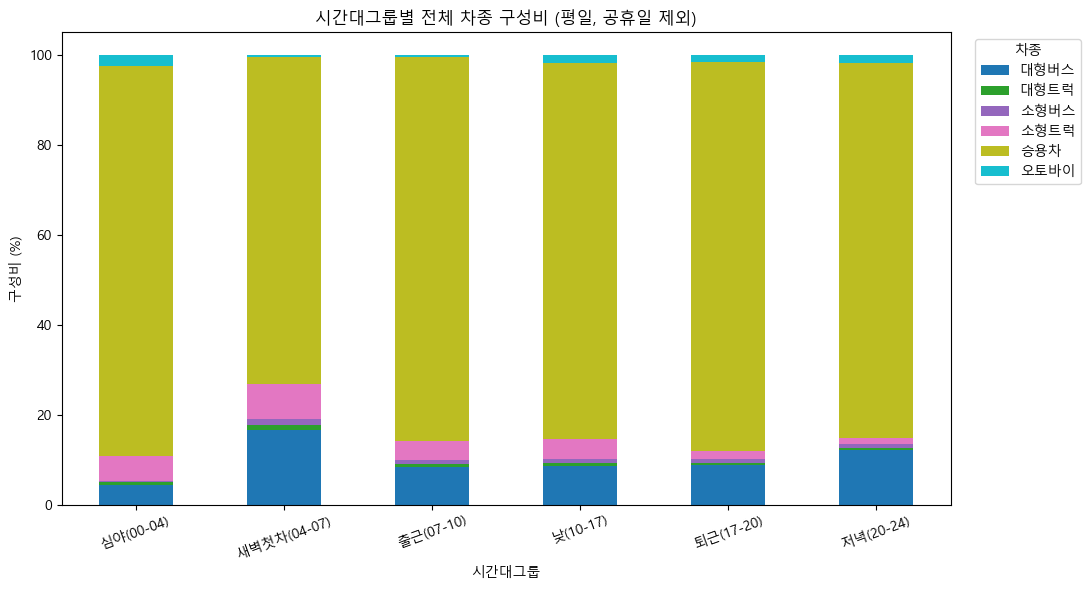

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

overall_by_band = vol_agg.groupby(['time_band', 'CarModelName'], observed=True)['Volume'].sum().unstack()
overall_pct = overall_by_band.div(overall_by_band.sum(axis=1), axis=0) * 100
overall_pct = overall_pct.reindex(BAND_ORDER)

overall_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('시간대그룹별 전체 차종 구성비 (평일, 공휴일 제외)')
ax.set_xlabel('시간대그룹')
ax.set_ylabel('구성비 (%)')
ax.legend(title='차종', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb01_시간대별_차종구성비.png', dpi=150)
plt.show()


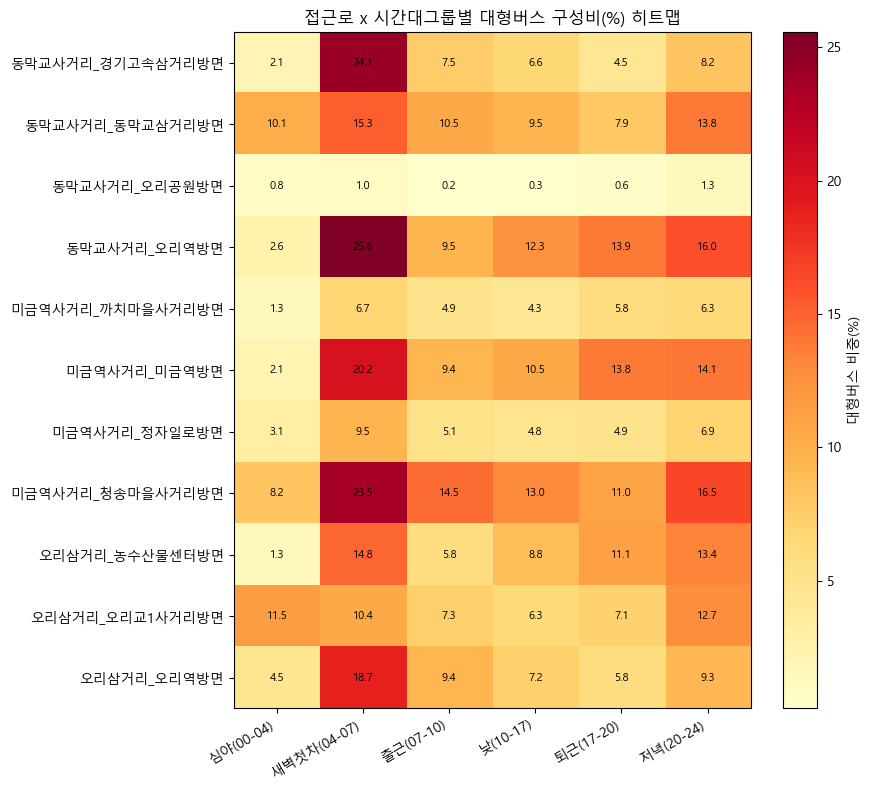

In [18]:
fig, ax = plt.subplots(figsize=(9, 8))
heat_data = pct.reset_index().pivot(index='AvenueName', columns='time_band', values='대형버스')[BAND_ORDER]
im = ax.imshow(heat_data.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(BAND_ORDER)))
ax.set_xticklabels(BAND_ORDER, rotation=30, ha='right')
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index)
ax.set_title('접근로 x 시간대그룹별 대형버스 구성비(%) 히트맵')
fig.colorbar(im, ax=ax, label='대형버스 비중(%)')
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        ax.text(j, i, f'{heat_data.values[i,j]:.1f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb01_대형버스_히트맵.png', dpi=150)
plt.show()


## 8. 결과 저장

다음 노트북(02: 시간대그룹 재검증 + 군집화)에서 바로 이어서 쓸 수 있도록 저장합니다.

In [19]:
pct_out = pct.reset_index()
pct_out.to_csv(PROCESSED_DIR / '접근로x시간대_차종구성비.csv', index=False, encoding='utf-8-sig')
cell_sample_size.to_csv(PROCESSED_DIR / '셀별_표본크기.csv', index=False, encoding='utf-8-sig')

print('저장 완료:')
print(f'  {PROCESSED_DIR / "접근로x시간대_차종구성비.csv"}')
print(f'  {PROCESSED_DIR / "셀별_표본크기.csv"}')


저장 완료:
  ..\data\processed\접근로x시간대_차종구성비.csv
  ..\data\processed\셀별_표본크기.csv


## 9. 다음 단계

이 노트북 실행 결과(특히 7절 품질 진단, 8절 저장된 CSV)를 확인한 뒤 채팅방에 결과를 다시
공유해주시면, 이상 없을 경우 **노트북 02(시간대그룹 최종 확인 + 군집화)**로 진행합니다.

체크할 것:
- 2-1절: `AvenueName` 중복(같은 이름, 다른 AvenueSeq)이 실제로 발견되는지, `UniqueLabel` 기준으로는
  11개가 유일하게 구분되는지
- 3절 검증 셀에서 AssertionError 없이 통과했는지 (원본 행수 3,660,588 일치)
- 6절에서 관측치 수가 정확히 66개인지 (11개 접근로 x 6개 시간대그룹)
- 7-1절 표본 크기가 극단적으로 작은 셀이 있는지
- 7-3절 그래프가 분석설계서 4절 근거(버스 첫차 스파이크 등)와 일치하는 모양인지
